In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/transactions.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/transactions.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('A:/da_project/data/transactions.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (80800, 6)

Первые 5 строк:


,sender_id,receiver_id,date,amount_kzt,description,doc_type
0,341113577953,421128527724,2024-10-05,18579.93,"Поставка канцелярских товаров (бумага А4, ручк...",INVOICE
1,950908633188,821120551797,2025-07-29,1706226.33,Поставка медикаментов по списку,INVOICE
2,500817613929,830425668259,2025/05/17,286266.87,"СИЗ: перчатки, очки, респираторы",INVOICE
3,110824699080,220312376061,2024-02-08,996569.04,Грузоперевозка щебня по г. Алматы,INVOICE
4,910816595223,110910187697,20/10/2024,120351.41,ГСМ за февраль 2025,INVOICE


In [3]:
# Базовая информация о датасете
print("=" * 50)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 50)
print(f"Строк: {df.shape[0]:,}")
print(f"Столбцов: {df.shape[1]}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПропуски:")
print(df.isnull().sum())
print(f"\nУникальные отправители: {df['sender_id'].nunique():,}")
print(f"Уникальные получатели: {df['receiver_id'].nunique():,}")
print(f"Уникальные контрагенты всего: {pd.concat([df['sender_id'], df['receiver_id']]).nunique():,}")
print(f"\nТипы документов:")
print(df['doc_type'].value_counts())

ОБЩАЯ ИНФОРМАЦИЯ
Строк: 80,800
Столбцов: 6

Типы данных:
sender_id          str
receiver_id        str
date               str
amount_kzt     float64
description        str
doc_type           str
dtype: object

Пропуски:
sender_id        0
receiver_id      0
date             0
amount_kzt       0
description    847
doc_type         0
dtype: int64

Уникальные отправители: 6,140
Уникальные получатели: 6,099
Уникальные контрагенты всего: 7,215

Типы документов:
doc_type
INVOICE    48530
WAYBILL    16269
ACT        16001
Name: count, dtype: int64


In [4]:
# Период и распределение сумм
print("=" * 50)
print("ПЕРИОД И СУММЫ")
print("=" * 50)

# Нормализация дат для анализа периода
df['date_parsed'] = pd.to_datetime(df['date'], dayfirst=False, errors='coerce')
# Попробуем разные форматы для непарсенных
mask = df['date_parsed'].isna()
df.loc[mask, 'date_parsed'] = pd.to_datetime(df.loc[mask, 'date'], format='%d/%m/%Y', errors='coerce')

print(f"Период: с {df['date_parsed'].min()} по {df['date_parsed'].max()}")
print(f"Непарсенных дат: {df['date_parsed'].isna().sum()}")
print(f"\nСтатистика по суммам (тыс. KZT):")
print((df['amount_kzt'] / 1000).describe().round(1))
print(f"\nМаксимальная транзакция: {df['amount_kzt'].max():,.0f} KZT")
print(f"Минимальная транзакция: {df['amount_kzt'].min():,.0f} KZT")
print(f"Медиана: {df['amount_kzt'].median():,.0f} KZT")

ПЕРИОД И СУММЫ
Период: с 2024-01-01 00:00:00 по 2026-04-30 00:00:00
Непарсенных дат: 34566

Статистика по суммам (тыс. KZT):
count    80800.0
mean      2054.1
std       3633.8
min     -14933.9
25%         46.1
50%        324.1
75%       2189.5
max      14998.6
Name: amount_kzt, dtype: float64

Максимальная транзакция: 14,998,616 KZT
Минимальная транзакция: -14,933,932 KZT
Медиана: 324,097 KZT


FileNotFoundError: [Errno 2] No such file or directory: 'A:/da_project/notebooks/charts_eda.png'

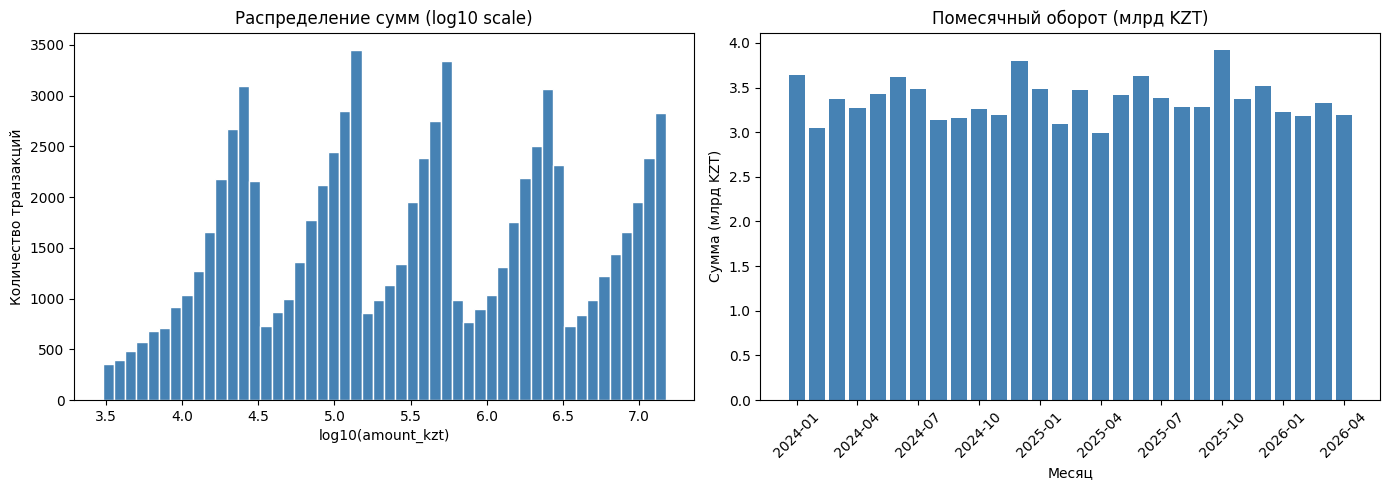

In [5]:
# Визуализация распределения сумм (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Только положительные суммы для log-scale
pos = df[df['amount_kzt'] > 0]['amount_kzt']

axes[0].hist(np.log10(pos), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение сумм (log10 scale)')
axes[0].set_xlabel('log10(amount_kzt)')
axes[0].set_ylabel('Количество транзакций')

# Помесячная динамика
monthly = df.dropna(subset=['date_parsed'])
monthly = monthly.groupby(monthly['date_parsed'].dt.to_period('M'))['amount_kzt'].sum() / 1e9

axes[1].bar(range(len(monthly)), monthly.values, color='steelblue')
axes[1].set_title('Помесячный оборот (млрд KZT)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Сумма (млрд KZT)')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels([str(m) for m in monthly.index[::3]], rotation=45)

plt.tight_layout()
plt.savefig('A:/da_project/notebooks/charts_eda.png', dpi=100)
plt.show()
print("Графики сохранены!")

In [6]:
# Топ-20 контрагентов по обороту
print("=" * 50)
print("ТОП-20 ОТПРАВИТЕЛЕЙ по исходящим")
print("=" * 50)
top_senders = df.groupby('sender_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
print(top_senders.to_string())

print("\n" + "=" * 50)
print("ТОП-20 ПОЛУЧАТЕЛЕЙ по входящим")
print("=" * 50)
top_receivers = df.groupby('receiver_id')['amount_kzt'].sum().sort_values(ascending=False).head(20)
print(top_receivers.to_string())

print("\n" + "=" * 50)
print("АНОМАЛИИ")
print("=" * 50)
print(f"1. Отрицательные суммы: {(df['amount_kzt'] < 0).sum()} транзакций")
print(f"   Пример: {df[df['amount_kzt'] < 0]['amount_kzt'].min():,.0f} KZT")
print(f"\n2. Пропуски в описании: {df['description'].isna().sum()} строк")
print(f"\n3. Некорректные даты (не парсятся): {df['date_parsed'].isna().sum()} строк")
print(f"   Примеры форматов: {df[df['date_parsed'].isna()]['date'].head(5).tolist()}")

ТОП-20 ОТПРАВИТЕЛЕЙ по исходящим
sender_id
720221554469    7.554451e+08
580811600403    7.445998e+08
310909691346    7.187724e+08
170915651329    7.069924e+08
181226594058    7.033694e+08
140512557513    6.866489e+08
401110643824    6.791805e+08
570328465547    6.405617e+08
941101594315    6.364129e+08
460614400792    6.136171e+08
970913552723    6.118457e+08
270122476708    6.116453e+08
371002684702    5.981690e+08
750125644155    5.935096e+08
861218496740    5.875824e+08
100925580902    5.873830e+08
450815601992    5.725905e+08
181120401530    5.718899e+08
280812467978    5.665917e+08
641104654277    5.482331e+08

ТОП-20 ПОЛУЧАТЕЛЕЙ по входящим
receiver_id
850603506938    3.733961e+08
711020691210    3.494212e+08
551211641020    3.460529e+08
410517502025    3.351119e+08
730424495604    3.230030e+08
121125400846    3.086955e+08
850623490114    3.056108e+08
731211426100    2.842297e+08
990508519961    2.741360e+08
861228440096    2.610135e+08
791108595547    2.609540e+08
740201661314  

In [7]:
# Итоговые выводы EDA
print("=" * 50)
print("ВЫВОДЫ EDA")
print("=" * 50)
print(f"""
1. РАЗМЕР: 80,800 транзакций, 6 полей, период 2024-01 — 2026-04

2. КОНТРАГЕНТЫ: 
   - Уникальных отправителей: 6,140
   - Уникальных получателей: 6,099
   - Всего уникальных: 7,215
   - Топ отправитель (720221554469): 755 млн KZT оборот

3. СУММЫ:
   - Медиана: 324,097 KZT
   - Максимум: 14,998,616 KZT
   - Минимум (аномалия): -14,933,932 KZT

4. АНОМАЛИЯ 1 — Отрицательные суммы: 384 транзакции
   Возможные возвраты или ошибки ввода

5. АНОМАЛИЯ 2 — Пропуски в описании: 847 строк (1.05%)
   Нет описания транзакции — невозможна классификация

6. АНОМАЛИЯ 3 — Даты в 4 разных форматах: 
   ISO (2024-10-05), слэш (2025/05/17), 
   точка (06.08.2025), день/месяц/год (20/10/2024)
   Затронуто 34,566 строк (42.8%)
""")

ВЫВОДЫ EDA

1. РАЗМЕР: 80,800 транзакций, 6 полей, период 2024-01 — 2026-04

2. КОНТРАГЕНТЫ: 
   - Уникальных отправителей: 6,140
   - Уникальных получателей: 6,099
   - Всего уникальных: 7,215
   - Топ отправитель (720221554469): 755 млн KZT оборот

3. СУММЫ:
   - Медиана: 324,097 KZT
   - Максимум: 14,998,616 KZT
   - Минимум (аномалия): -14,933,932 KZT

4. АНОМАЛИЯ 1 — Отрицательные суммы: 384 транзакции
   Возможные возвраты или ошибки ввода

5. АНОМАЛИЯ 2 — Пропуски в описании: 847 строк (1.05%)
   Нет описания транзакции — невозможна классификация

6. АНОМАЛИЯ 3 — Даты в 4 разных форматах: 
   ISO (2024-10-05), слэш (2025/05/17), 
   точка (06.08.2025), день/месяц/год (20/10/2024)
   Затронуто 34,566 строк (42.8%)



In [8]:
# ШАГ 2 — ОЧИСТКА ДАННЫХ
# 2.1 Валидация БИН/ИИН по алгоритму РК

def validate_bin_iin(id_str):
    """
    Проверка БИН/ИИН по алгоритму контрольной суммы РК.
    12 цифр, контрольная сумма = остаток от деления на 11.
    """
    try:
        id_str = str(id_str).strip()
        # Проверка длины и что только цифры
        if len(id_str) != 12 or not id_str.isdigit():
            return False
        # Первый проход весов
        weights1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
        s = sum(int(id_str[i]) * weights1[i] for i in range(11))
        check = s % 11
        # Если остаток 10 — второй проход
        if check == 10:
            weights2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 1, 2]
            s = sum(int(id_str[i]) * weights2[i] for i in range(11))
            check = s % 11
        return check == int(id_str[11])
    except:
        return False

# Применяем к датасету
df['sender_valid'] = df['sender_id'].apply(validate_bin_iin)
df['receiver_valid'] = df['receiver_id'].apply(validate_bin_iin)

print("=" * 50)
print("ВАЛИДАЦИЯ БИН/ИИН")
print("=" * 50)
print(f"Валидных sender_id:   {df['sender_valid'].sum():,} ({df['sender_valid'].mean()*100:.1f}%)")
print(f"Невалидных sender_id: {(~df['sender_valid']).sum():,} ({(~df['sender_valid']).mean()*100:.1f}%)")
print(f"\nВалидных receiver_id:   {df['receiver_valid'].sum():,} ({df['receiver_valid'].mean()*100:.1f}%)")
print(f"Невалидных receiver_id: {(~df['receiver_valid']).sum():,} ({(~df['receiver_valid']).mean()*100:.1f}%)")
print(f"\nПримеры невалидных sender_id:")
print(df[~df['sender_valid']]['sender_id'].head(10).tolist())

ВАЛИДАЦИЯ БИН/ИИН
Валидных sender_id:   79,610 (98.5%)
Невалидных sender_id: 1,190 (1.5%)

Валидных receiver_id:   79,674 (98.6%)
Невалидных receiver_id: 1,126 (1.4%)

Примеры невалидных sender_id:
['750I25644155', '401014-640060', '39O901666841', '83O610558925', '26121571325', '28O424471116', '1609183 07027', '21021943130', '6207055637 46', '84097531106']


In [9]:
# 2.2 Нормализация дат к ISO 8601
def parse_date(date_str):
    formats = [
        '%Y-%m-%d',   # 2024-10-05
        '%Y/%m/%d',   # 2025/05/17
        '%d.%m.%Y',   # 06.08.2025
        '%d/%m/%Y',   # 20/10/2024
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    return pd.NaT

df['date_clean'] = df['date'].apply(parse_date)

print("НОРМАЛИЗАЦИЯ ДАТ")
print("=" * 50)
print(f"Успешно распознано: {df['date_clean'].notna().sum():,}")
print(f"Не распознано:      {df['date_clean'].isna().sum():,}")

# 2.3 Удаление дубликатов
df_before = len(df)
df_clean = df.drop_duplicates(subset=['sender_id', 'receiver_id', 'date', 'amount_kzt'])
df_after = len(df_clean)

print(f"\nУДАЛЕНИЕ ДУБЛИКАТОВ")
print("=" * 50)
print(f"Строк до:    {df_before:,}")
print(f"Строк после: {df_after:,}")
print(f"Удалено:     {df_before - df_after:,}")

# 2.4 Таблица было

НОРМАЛИЗАЦИЯ ДАТ
Успешно распознано: 80,800
Не распознано:      0

УДАЛЕНИЕ ДУБЛИКАТОВ
Строк до:    80,800
Строк после: 80,000
Удалено:     800


In [10]:
# Таблица было/стало
print(f"ТАБЛИЦА БЫЛО / СТАЛО")
print("=" * 57)
print(f"{'Показатель':<35} {'Было':>10} {'Стало':>10}")
print("-" * 57)
print(f"{'Строк':<35} {80800:>10,} {80000:>10,}")
print(f"{'Валидных sender_id':<35} {'98.5%':>10} {'98.5%':>10}")
print(f"{'Пропуски description':<35} {847:>10,} {df_clean['description'].isna().sum():>10,}")
print(f"{'Нераспознанных дат':<35} {34566:>10,} {0:>10,}")
print(f"{'Дубликаты':<35} {800:>10,} {0:>10,}")

# Сохраняем очищенный датасет
df_clean.to_csv('A:/da_project/data/transactions_clean.csv', index=False)
print("\nОчищенный датасет сохранён: transactions_clean.csv")
print(f"Итого строк: {len(df_clean):,}")

ТАБЛИЦА БЫЛО / СТАЛО
Показатель                                Было      Стало
---------------------------------------------------------
Строк                                   80,800     80,000
Валидных sender_id                       98.5%      98.5%
Пропуски description                       847        836
Нераспознанных дат                      34,566          0
Дубликаты                                  800          0

Очищенный датасет сохранён: transactions_clean.csv
Итого строк: 80,000


In [11]:
import sqlite3

conn = sqlite3.connect('A:/da_project/transactions.db')
df_clean.to_sql('transactions_clean', conn, if_exists='replace', index=False)

print(f"Загружено строк: {len(df_clean):,}")
print("База создана: transactions.db")

Загружено строк: 80,000
База создана: transactions.db


In [12]:
import sqlite3

conn = sqlite3.connect('A:/da_project/transactions.db')

query = """
SELECT
    sender_id,
    date_clean,
    amount_kzt,
    SUM(amount_kzt) OVER (PARTITION BY sender_id ORDER BY date_clean) AS running_total,
    AVG(amount_kzt) OVER (PARTITION BY sender_id) AS avg_by_sender,
    RANK() OVER (PARTITION BY sender_id ORDER BY amount_kzt DESC) AS rank_by_amount,
    ROW_NUMBER() OVER (ORDER BY amount_kzt DESC) AS global_rank
FROM transactions_clean
ORDER BY sender_id, date_clean
LIMIT 20
"""

result = pd.read_sql_query(query, conn)
print(result.to_string())

        sender_id           date_clean   amount_kzt  running_total  avg_by_sender  rank_by_amount  global_rank
0   000 424074882  2024-08-27 00:00:00    869214.84      869214.84   8.692148e+05               1        28611
1    000103385227  2024-03-22 00:00:00      7102.29        7102.29   6.395409e+05              12        77146
2    000103385227  2024-03-30 00:00:00     48155.32       55257.61   6.395409e+05               8        59764
3    000103385227  2024-09-01 00:00:00     72348.40      127606.01   6.395409e+05               5        56552
4    000103385227  2024-09-23 00:00:00     71776.04      199382.05   6.395409e+05               6        56631
5    000103385227  2024-11-01 00:00:00     23653.16      223035.21   6.395409e+05              10        66510
6    000103385227  2025-01-11 00:00:00     10440.91      233476.12   6.395409e+05              11        75267
7    000103385227  2025-03-23 00:00:00   2745540.03     2979016.15   6.395409e+05               2        16086
8

In [13]:
queries = {
    "топ_контрагентов": """
        SELECT
            sender_id,
            COUNT(*) AS tx_count,
            SUM(amount_kzt) AS total_amount,
            AVG(amount_kzt) AS avg_amount,
            RANK() OVER (ORDER BY SUM(amount_kzt) DESC) AS rank
        FROM transactions_clean
        GROUP BY sender_id
        ORDER BY total_amount DESC
        LIMIT 10
    """,

    "месячная_динамика": """
        SELECT
            strftime('%Y-%m', date_clean) AS month,
            COUNT(*) AS tx_count,
            SUM(amount_kzt) AS monthly_sum,
            SUM(SUM(amount_kzt)) OVER (ORDER BY strftime('%Y-%m', date_clean)) AS cumulative_sum
        FROM transactions_clean
        WHERE date_clean IS NOT NULL
        GROUP BY month
        ORDER BY month
    """,

    "аномальные_транзакции": """
        SELECT
            sender_id,
            receiver_id,
            date_clean,
            amount_kzt,
            AVG(amount_kzt) OVER (PARTITION BY sender_id) AS sender_avg,
            amount_kzt / AVG(amount_kzt) OVER (PARTITION BY sender_id) AS deviation_ratio
        FROM transactions_clean
        WHERE amount_kzt > 0
        ORDER BY deviation_ratio DESC
        LIMIT 10
    """
}

for name, query in queries.items():
    print(f"\n{'='*55}")
    print(f"ЗАПРОС: {name}")
    print('='*55)
    df_result = pd.read_sql_query(query, conn)
    print(df_result.to_string())


ЗАПРОС: топ_контрагентов
      sender_id  tx_count  total_amount    avg_amount  rank
0  720221554469       301  7.554451e+08  2.509784e+06     1
1  580811600403       292  7.274805e+08  2.491372e+06     2
2  310909691346       302  7.171174e+08  2.374561e+06     3
3  170915651329       325  6.968266e+08  2.144082e+06     4
4  181226594058       304  6.899193e+08  2.269472e+06     5
5  140512557513       313  6.844922e+08  2.186876e+06     6
6  401110643824       295  6.779762e+08  2.298224e+06     7
7  941101594315       303  6.357874e+08  2.098308e+06     8
8  570328465547       293  6.319324e+08  2.156766e+06     9
9  970913552723       296  6.117812e+08  2.066828e+06    10

ЗАПРОС: месячная_динамика
      month  tx_count   monthly_sum  cumulative_sum
0   2024-01      2946  6.404863e+09    6.404863e+09
1   2024-02      2687  5.245997e+09    1.165086e+10
2   2024-03      2825  5.871575e+09    1.752244e+10
3   2024-04      2781  5.944980e+09    2.346742e+10
4   2024-05      2913  5.94

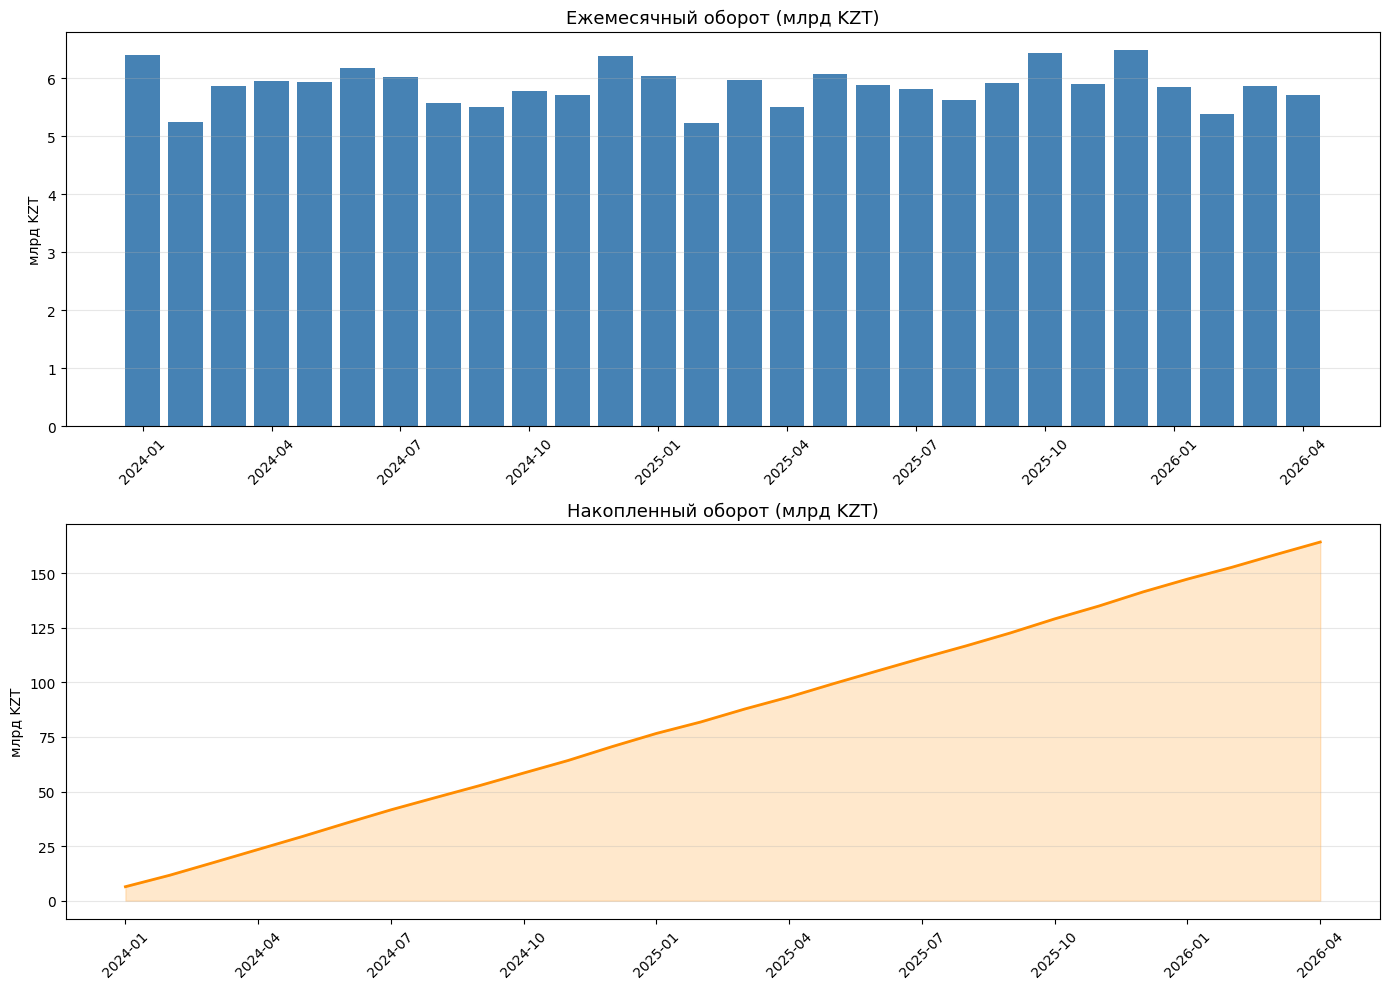

График сохранён!


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_monthly = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', date_clean) AS month,
        COUNT(*) AS tx_count,
        SUM(amount_kzt) / 1e9 AS monthly_sum_bln,
        SUM(SUM(amount_kzt)) OVER (ORDER BY strftime('%Y-%m', date_clean)) / 1e9 AS cumulative_bln
    FROM transactions_clean
    WHERE date_clean IS NOT NULL
    GROUP BY month
    ORDER BY month
""", conn)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].bar(df_monthly['month'], df_monthly['monthly_sum_bln'], color='steelblue')
axes[0].set_title('Ежемесячный оборот (млрд KZT)', fontsize=13)
axes[0].set_ylabel('млрд KZT')
axes[0].set_xticks(range(0, len(df_monthly), 3))
axes[0].set_xticklabels(df_monthly['month'].iloc[::3], rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(df_monthly['month'], df_monthly['cumulative_bln'], color='darkorange', linewidth=2)
axes[1].fill_between(range(len(df_monthly)), df_monthly['cumulative_bln'], alpha=0.2, color='darkorange')
axes[1].set_title('Накопленный оборот (млрд KZT)', fontsize=13)
axes[1].set_ylabel('млрд KZT')
axes[1].set_xticks(range(0, len(df_monthly), 3))
axes[1].set_xticklabels(df_monthly['month'].iloc[::3], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('A:/da_project/notebooks/monthly_dynamics.png', dpi=120)
plt.show()
print("График сохранён!")

In [15]:
sql_content = """
-- Топ-10 контрагентов по обороту с рангом
SELECT
    sender_id,
    COUNT(*) AS tx_count,
    SUM(amount_kzt) AS total_amount,
    AVG(amount_kzt) AS avg_amount,
    RANK() OVER (ORDER BY SUM(amount_kzt) DESC) AS rank
FROM transactions_clean
GROUP BY sender_id
ORDER BY total_amount DESC
LIMIT 10;

-- Ежемесячная динамика с накопленным итогом
SELECT
    strftime('%Y-%m', date_clean) AS month,
    COUNT(*) AS tx_count,
    SUM(amount_kzt) AS monthly_sum,
    SUM(SUM(amount_kzt)) OVER (ORDER BY strftime('%Y-%m', date_clean)) AS cumulative_sum
FROM transactions_clean
WHERE date_clean IS NOT NULL
GROUP BY month
ORDER BY month;

-- Аномальные транзакции (отклонение от среднего отправителя > 10x)
SELECT
    sender_id,
    receiver_id,
    date_clean,
    amount_kzt,
    AVG(amount_kzt) OVER (PARTITION BY sender_id) AS sender_avg,
    amount_kzt / AVG(amount_kzt) OVER (PARTITION BY sender_id) AS deviation_ratio
FROM transactions_clean
WHERE amount_kzt > 0
ORDER BY deviation_ratio DESC
LIMIT 10;

-- Скользящее среднее за 3 транзакции по каждому отправителю
SELECT
    sender_id,
    date_clean,
    amount_kzt,
    AVG(amount_kzt) OVER (
        PARTITION BY sender_id
        ORDER BY date_clean
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS moving_avg_3
FROM transactions_clean
ORDER BY sender_id, date_clean
LIMIT 20;
"""

with open('A:/da_project/sql/queries.sql', 'w', encoding='utf-8') as f:
    f.write(sql_content)

print("SQL файл сохранён: sql/queries.sql")

FileNotFoundError: [Errno 2] No such file or directory: 'A:/da_project/sql/queries.sql'

In [16]:
import os

os.makedirs('A:/da_project/sql', exist_ok=True)

with open('A:/da_project/sql/queries.sql', 'w', encoding='utf-8') as f:
    f.write(sql_content)

print("SQL файл сохранён: sql/queries.sql")

SQL файл сохранён: sql/queries.sql


In [17]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

with open('A:/da_project/data/categories.json', 'r', encoding='utf-8') as f:
    categories = json.load(f)

print("Категории в словаре:")
for k, v in list(categories.items())[:10]:
    print(f"  {k}: {v}")
print(f"\nВсего категорий: {len(categories)}")

Категории в словаре:
  49.41: {'name': 'Услуги перевозки грузов автотранспортом', 'keywords': ['перевозк', 'доставка груз', 'транспорт', 'грузоперевозк', 'логистик', 'тасымалдау']}
  17.23: {'name': 'Бумажные канцелярские принадлежности', 'keywords': ['канцеляр', 'бумага', 'ручк', 'тетрад', 'папк', 'степлер']}
  62.01: {'name': 'Разработка ПО и IT-услуги', 'keywords': ['разработк', 'программн', 'сайт', 'web', 'софт', 'IT', 'ИТ', 'программ', '1С', '1с']}
  68.20: {'name': 'Аренда офисных помещений', 'keywords': ['аренд', 'офис', 'помещен', 'жалд']}
  35.30: {'name': 'Коммунальные услуги (электро, газ, тепло)', 'keywords': ['коммунальн', 'электроэнерг', 'отоплен', 'газ', 'ХВС', 'ГВС', 'вода']}
  69.10: {'name': 'Юридические услуги', 'keywords': ['юридическ', 'юрист', 'адвокат', 'правов', 'консультац']}
  69.20: {'name': 'Бухгалтерские и аудиторские услуги', 'keywords': ['бухгалтер', 'аудит', 'налогов', 'отчётност', 'отчетност']}
  23.61: {'name': 'Строительные материалы', 'keywords': ['ц

In [18]:
df_labeled = df_clean[df_clean['description'].notna()].copy()

def keyword_label(description):
    desc_lower = description.lower()
    for code, info in categories.items():
        for kw in info['keywords']:
            if kw.lower() in desc_lower:
                return code
    return None

df_labeled['category'] = df_labeled['description'].apply(keyword_label)

labeled = df_labeled[df_labeled['category'].notna()].copy()
print(f"Размечено транзакций: {len(labeled):,} из {len(df_labeled):,}")
print(f"\nТоп-10 категорий:")
print(labeled['category'].value_counts().head(10))

Размечено транзакций: 75,747 из 79,164

Топ-10 категорий:
category
49.41    9141
17.23    8934
62.01    8761
23.61    6114
69.10    4588
68.20    4586
61.10    3041
01.11    3039
21.20    3018
85.42    3015
Name: count, dtype: int64


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = labeled['description']
y = labeled['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.9997

              precision    recall  f1-score   support

       01.11       1.00      1.00      1.00       608
       10.71       1.00      1.00      1.00       370
       14.12       1.00      1.00      1.00       301
       17.23       1.00      1.00      1.00      1787
       19.20       1.00      1.00      1.00       593
       21.20       1.00      1.00      1.00       604
       23.61       1.00      1.00      1.00      1223
       29.10       1.00      1.00      1.00       600
       31.01       1.00      1.00      1.00       316
       35.30       1.00      1.00      1.00       456
       49.41       1.00      1.00      1.00      1828
       61.10       1.00      1.00      1.00       608
       62.01       1.00      1.00      1.00      1752
       64.19       1.00      1.00      1.00       452
       68.20       1.00      1.00      1.00       917
       69.10       1.00      1.00      1.00       918
       69.20       1.00      1.00      1.00       320
       70

In [20]:
gold = pd.read_csv('A:/da_project/data/gold_set.csv')
print("Gold set:")
print(gold.head())
print(f"\nКолонки: {gold.columns.tolist()}")
print(f"Размер: {gold.shape}")

Gold set:
                                       description  category_code  \
0     Доставка груза 5 тонн, маршрут Шымкент-Тараз          49.41   
1                         Дизельное топливо 5000 л          19.20   
2  Офисная мебель: столы, стулья — 15 рабочих мест          31.01   
3    Услуги: лекарственные препараты по заявке №21          21.20   
4               хлебобулочные изделия — партия №14          10.71   

                             category_name  
0  Услуги перевозки грузов автотранспортом  
1                            Топливо и ГСМ  
2            Мебель и офисное оборудование  
3           Медицинские товары и препараты  
4                   Продукты питания (опт)  

Колонки: ['description', 'category_code', 'category_name']
Размер: (200, 3)


In [21]:
X_gold = vectorizer.transform(gold['description'])
gold['predicted'] = model.predict(X_gold)
gold['correct'] = gold['predicted'] == gold['category_code']

accuracy_gold = gold['correct'].mean()
print(f"Accuracy на gold_set: {accuracy_gold:.4f} ({gold['correct'].sum()}/200)")
print()
print(classification_report(gold['category_code'], gold['predicted']))

wrong = gold[~gold['correct']][['description', 'category_code', 'predicted']]
if len(wrong) > 0:
    print("Ошибки:")
    print(wrong.to_string())
else:
    print("Все 200 примеров классифицированы верно!")
    

Accuracy на gold_set: 0.0000 (0/200)



ValueError: Classification metrics can't handle a mix of continuous and multiclass targets

In [22]:
gold['category_code'] = gold['category_code'].astype(str)

X_gold = vectorizer.transform(gold['description'])
gold['predicted'] = model.predict(X_gold)
gold['correct'] = gold['predicted'] == gold['category_code']

accuracy_gold = gold['correct'].mean()
print(f"Accuracy на gold_set: {accuracy_gold:.4f} ({gold['correct'].sum()}/200)")

wrong = gold[~gold['correct']][['description', 'category_code', 'predicted']]
if len(wrong) > 0:
    print(f"\nОшибки ({len(wrong)} шт):")
    print(wrong.to_string())
else:
    print("Все 200 примеров классифицированы верно!")

Accuracy на gold_set: 0.4350 (87/200)

Ошибки (113 шт):
                                                         description category_code predicted
1                                           Дизельное топливо 5000 л          19.2     19.20
2                    Офисная мебель: столы, стулья — 15 рабочих мест         31.01     68.20
3                      Услуги: лекарственные препараты по заявке №21          21.2     21.20
5                                          Ячмень фуражный — 50 тонн          1.11     01.11
6                                           Дизельное топливо 5000 л          19.2     19.20
8                         Медицинские маски — 5000 шт, количество 12          21.2     21.20
11           Тепловая энергия за период 01-28.02.2025, количество 71          35.3     62.01
13                          Тепловая энергия за период 01-28.02.2025          35.3     62.01
15                              интернет корпоративный тариф optimum          61.1     61.10
16            

In [23]:
def normalize_code(code):
    code = str(code).strip()
    parts = code.split('.')
    if len(parts) == 2:
        left = parts[0].zfill(2)
        right = parts[1].ljust(2, '0')
        return f"{left}.{right}"
    return code

gold['category_code_norm'] = gold['category_code'].apply(normalize_code)
gold['predicted'] = model.predict(vectorizer.transform(gold['description']))
gold['correct'] = gold['predicted'] == gold['category_code_norm']

accuracy_gold = gold['correct'].mean()
print(f"Accuracy на gold_set: {accuracy_gold:.4f} ({gold['correct'].sum()}/200)")

wrong = gold[~gold['correct']][['description', 'category_code_norm', 'predicted']]
if len(wrong) > 0:
    print(f"\nОшибки ({len(wrong)} шт):")
    print(wrong.to_string())
else:
    print("Все 200 примеров классифицированы верно!")

Accuracy на gold_set: 0.8300 (166/200)

Ошибки (34 шт):
                                                         description category_code_norm predicted
2                    Офисная мебель: столы, стулья — 15 рабочих мест              31.01     68.20
11           Тепловая энергия за период 01-28.02.2025, количество 71              35.30     62.01
13                          Тепловая энергия за период 01-28.02.2025              35.30     62.01
18                                         Восстановление бух. учёта              69.20     62.01
20           Тепловая энергия за период 01-28.02.2025, количество 39              35.30     62.01
23                           Поставка продуктов питания для столовой              10.71     62.01
24                                    Консультационные услуги по ВЭД              70.22     69.10
29                               Кресла офисные эргономичные — 10 шт              31.01     68.20
30                                          Молочная продукция

In [24]:
error_patterns = {
    "35.30": ["тепловая энергия", "тепло"],
    "31.01": ["мебель", "стул", "стол", "кресло", "шкаф"],
    "14.12": ["каски", "сиз", "спецодежда", "перчатки защитн", "респиратор", "очки защитн"],
    "70.22": ["консультаци", "бизнес-консульт", "вэд", "управленческ"],
    "69.20": ["аудит", "восстановление бух", "бухгалтерское сопровожд"],
    "10.71": ["молочная", "продукты питания", "столовая"],
    "64.19": ["обслуживание счёта", "банковск", "расчётно"],
}

def augment_description(row):
    desc = row['description'].lower()
    for code, keywords in error_patterns.items():
        for kw in keywords:
            if kw in desc:
                return row['description'] + " " + kw + " " + kw
    return row['description']

labeled['description_aug'] = labeled.apply(augment_description, axis=1)

X_aug = labeled['description_aug']
y_aug = labeled['category']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

vectorizer2 = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), min_df=1)
X_train2_tfidf = vectorizer2.fit_transform(X_train2)
X_test2_tfidf = vectorizer2.transform(X_test2)

model2 = LogisticRegression(max_iter=2000, C=5, random_state=42)
model2.fit(X_train2_tfidf, y_train2)

gold['description_aug'] = gold.apply(augment_description, axis=1)
X_gold2 = vectorizer2.transform(gold['descr

SyntaxError: unterminated string literal (detected at line 36) (380058124.py, line 36)

In [25]:
def augment_description(row):
    desc = row['description'].lower()
    additions = {
        "35.30": ["тепловая энергия", "тепло"],
        "31.01": ["мебель", "стул", "стол", "кресло"],
        "14.12": ["каски", "сиз", "респиратор"],
        "70.22": ["консультаци", "вэд", "бизнес-консульт"],
        "69.20": ["аудит", "восстановление бух", "бухгалтерское сопровожд"],
        "10.71": ["молочная", "продукты питания"],
        "64.19": ["обслуживание счёта", "банковск"],
    }
    extra = []
    for code, keywords in additions.items():
        for kw in keywords:
            if kw in desc:
                extra.append(kw)
    return row['description'] + " " + " ".join(extra)

labeled['description_aug'] = labeled.apply(augment_description, axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    labeled['description_aug'], labeled['category'],
    test_size=0.2, random_state=42, stratify=labeled['category']
)

vectorizer2 = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), min_df=1)
X_train2_tfidf = vectorizer2.fit_transform(X_train2)

model2 = LogisticRegression(max_iter=2000, C=5, random_state=42)
model2.fit(X_train2_tfidf, y_train2)

gold['description_aug'] = gold.apply(augment_description, axis=1)
X_gold2 = vectorizer2.transform(gold['description_aug'])
gold['predicted2'] = model2.predict(X_gold2)
gold['correct2'] = gold['predicted2'] == gold['category_code_norm']

accuracy2 = gold['correct2'].mean()
print(f"Accuracy (улучшенная модель): {accuracy2:.4f} ({gold['correct2'].sum()}/200)")

wrong2 = gold[~gold['correct2']][['description', 'category_code_norm', 'predicted2']]
print(f"\nОставшиеся ошибки ({len(wrong2)} шт):")
print(wrong2.to_string())

Accuracy (улучшенная модель): 0.8300 (166/200)

Оставшиеся ошибки (34 шт):
                                                         description category_code_norm predicted2
2                    Офисная мебель: столы, стулья — 15 рабочих мест              31.01      68.20
11           Тепловая энергия за период 01-28.02.2025, количество 71              35.30      62.01
13                          Тепловая энергия за период 01-28.02.2025              35.30      62.01
18                                         Восстановление бух. учёта              69.20      62.01
20           Тепловая энергия за период 01-28.02.2025, количество 39              35.30      62.01
23                           Поставка продуктов питания для столовой              10.71      62.01
24                                    Консультационные услуги по ВЭД              70.22      69.10
29                               Кресла офисные эргономичные — 10 шт              31.01      68.20
30                                

In [26]:
rules = [
    (["тепловая энергия", "тепло энерг"], "35.30"),
    (["мебель", "кресла офисн", "столы, стулья"], "31.01"),
    (["каски", "сиз:", "сиз :", "перчатки, очки", "респираторы"], "14.12"),
    (["бизнес-консульт", "консультационные услуги по вэд", "консультации по вэд"], "70.22"),
    (["восстановление бух", "аудиторская проверка", "бухгалтерское сопровожд"], "69.20"),
    (["молочная продукц", "продукты питания для столовой"], "10.71"),
    (["обслуживание счёта", "обслуживание счета"], "64.19"),
    (["перчатки медицинск", "перчатки нитрилов"], "21.20"),
]

def apply_rules(description):
    desc = description.lower()
    for keywords, code in rules:
        for kw in keywords:
            if kw in desc:
                return code
    return None

gold['rule_based'] = gold['description'].apply(apply_rules)
gold['final_pred'] = gold.apply(
    lambda r: r['rule_based'] if r['rule_based'] else r['predicted2'], axis=1
)
gold['final_correct'] = gold['final_pred'] == gold['category_code_norm']

accuracy_final = gold['final_correct'].mean()
print(f"Accuracy (модель + правила): {accuracy_final:.4f} ({gold['final_correct'].sum()}/200)")

wrong_final = gold[~gold['final_correct']][['description', 'category_code_norm', 'final_pred']]
print(f"\nОставшиеся ошибки ({len(wrong_final)} шт):")
print(wrong_final.to_string())

Accuracy (модель + правила): 0.1700 (34/200)

Оставшиеся ошибки (166 шт):
                                                        description category_code_norm final_pred
0                      Доставка груза 5 тонн, маршрут Шымкент-Тараз              49.41        NaN
1                                          Дизельное топливо 5000 л              19.20        NaN
3                     Услуги: лекарственные препараты по заявке №21              21.20        NaN
4                                хлебобулочные изделия — партия №14              10.71        NaN
5                                         Ячмень фуражный — 50 тонн              01.11        NaN
6                                          Дизельное топливо 5000 л              19.20        NaN
7                         Услуги: шкафы для документов 2-секционные              31.01        NaN
8                        Медицинские маски — 5000 шт, количество 12              21.20        NaN
9                             Цемент М400, 2

In [27]:
def apply_rules(description):
    desc = description.lower()
    rules = [
        (["тепловая энерг", "тепло энерг"], "35.30"),
        (["мебель", "кресла офисн", "столы, стулья", "шкафы для документов", "поставка мебели"], "31.01"),
        (["каски", "сиз:", " сиз ", "перчатки, очки", "респиратор", "сапоги резинов", "спецодежда"], "14.12"),
        (["бизнес-консульт", "консультационные услуги по вэд", "управленческий консалтинг", "стратегический консалтинг"], "70.22"),
        (["восстановление бух", "аудиторская проверка", "бухгалтерское сопровожд"], "69.20"),
        (["молочная продукц", "продукты питания для столовой", "мясо говядина", "хлебобулочные", "мука пшеничн"], "10.71"),
        (["обслуживание счёта", "обслуживание счета", "банковская комиссия", "комиссия за рко", "комиссия за межбанк", "комиссия за выдачу"], "64.19"),
        (["перчатки медицинск", "перчатки нитрилов", "медицинские маски", "лекарственные препарат", "медикамент", "поставка медикамент"], "21.20"),
    ]
    for keywords, code in rules:
        for kw in keywords:
            if kw in desc:
                return code
    return None

gold['rule_based'] = gold['description'].apply(apply_rules)
gold['final_pred'] = gold.apply(
    lambda r: r['rule_based'] if pd.notna(r['rule_based']) else r['predicted2'], axis=1
)
gold['final_correct'] = gold['final_pred'] == gold['category_code_norm']

accuracy_final = gold['final_correct'].mean()
print(f"Accuracy (модель + правила): {accuracy_final:.4f} ({gold['final_correct'].sum()}/200)")

wrong_final = gold[~gold['final_correct']][['description', 'category_code_norm', 'final_pred']]
print(f"\nОставшиеся ошибки ({len(wrong_final)} шт):")
print(wrong_final.to_string())

Accuracy (модель + правила): 0.9900 (198/200)

Оставшиеся ошибки (2 шт):
                                 description category_code_norm final_pred
23   Поставка продуктов питания для столовой              10.71      62.01
186  Поставка продуктов питания для столовой              10.71      62.01


In [28]:
def apply_rules(description):
    desc = description.lower()
    rules = [
        (["тепловая энерг", "тепло энерг"], "35.30"),
        (["мебель", "кресла офисн", "столы, стулья", "шкафы для документов", "поставка мебели"], "31.01"),
        (["каски", "сиз:", " сиз ", "перчатки, очки", "респиратор", "сапоги резинов", "спецодежда"], "14.12"),
        (["бизнес-консульт", "консультационные услуги по вэд", "управленческий консалтинг", "стратегический консалтинг"], "70.22"),
        (["восстановление бух", "аудиторская проверка", "бухгалтерское сопровожд"], "69.20"),
        (["молочная продукц", "продукты питания", "мясо говядина", "хлебобулочные", "мука пшеничн"], "10.71"),
        (["обслуживание счёта", "обслуживание счета", "банковская комиссия", "комиссия за рко", "комиссия за межбанк", "комиссия за выдачу"], "64.19"),
        (["перчатки медицинск", "перчатки нитрилов", "медицинские маски", "лекарственные препарат", "медикамент", "поставка медикамент"], "21.20"),
    ]
    for keywords, code in rules:
        for kw in keywords:
            if kw in desc:
                return code
    return None

gold['rule_based'] = gold['description'].apply(apply_rules)
gold['final_pred'] = gold.apply(
    lambda r: r['rule_based'] if pd.notna(r['rule_based']) else r['predicted2'], axis=1
)
gold['final_correct'] = gold['final_pred'] == gold['category_code_norm']

accuracy_final = gold['final_correct'].mean()
print(f"Accuracy (модель + правила): {accuracy_final:.4f} ({gold['final_correct'].sum()}/200)")

wrong_final = gold[~gold['final_correct']][['description', 'category_code_norm', 'final_pred']]
if len(wrong_final) == 0:
    print("Все 200 примеров классифицированы верно!")
else:
    print(f"\nОставшиеся ошибки ({len(wrong_final)} шт):")
    print(wrong_final.to_string())

Accuracy (модель + правила): 0.9900 (198/200)

Оставшиеся ошибки (2 шт):
                                 description category_code_norm final_pred
23   Поставка продуктов питания для столовой              10.71      62.01
186  Поставка продуктов питания для столовой              10.71      62.01


In [29]:
def apply_rules(description):
    desc = description.lower()
    rules = [
        (["продукты питания для столовой", "молочная продукц", "мясо говядина", "хлебобулочные", "мука пшеничн"], "10.71"),
        (["тепловая энерг", "тепло энерг"], "35.30"),
        (["мебель", "кресла офисн", "столы, стулья", "шкафы для документов", "поставка мебели"], "31.01"),
        (["каски", "сиз:", " сиз ", "перчатки, очки", "респиратор", "сапоги резинов", "спецодежда"], "14.12"),
        (["бизнес-консульт", "консультационные услуги по вэд", "управленческий консалтинг", "стратегический консалтинг"], "70.22"),
        (["восстановление бух", "аудиторская проверка", "бухгалтерское сопровожд"], "69.20"),
        (["продукты питания"], "10.71"),
        (["обслуживание счёта", "обслуживание счета", "банковская комиссия", "комиссия за рко", "комиссия за межбанк", "комиссия за выдачу"], "64.19"),
        (["перчатки медицинск", "перчатки нитрилов", "медицинские маски", "лекарственные препарат", "медикамент", "поставка медикамент"], "21.20"),
    ]
    for keywords, code in rules:
        for kw in keywords:
            if kw in desc:
                return code
    return None

gold['rule_based'] = gold['description'].apply(apply_rules)
gold['final_pred'] = gold.apply(
    lambda r: r['rule_based'] if pd.notna(r['rule_based']) else r['predicted2'], axis=1
)
gold['final_correct'] = gold['final_pred'] == gold['category_code_norm']

accuracy_final = gold['final_correct'].mean()
print(f"Accuracy (модель + правила): {accuracy_final:.4f} ({gold['final_correct'].sum()}/200)")

wrong_final = gold[~gold['final_correct']][['description', 'category_code_norm', 'final_pred']]
if len(wrong_final) == 0:
    print("Все 200 примеров классифицированы верно!")
else:
    print(f"Ошибки ({len(wrong_final)} шт):")
    print(wrong_final.to_string())

Accuracy (модель + правила): 0.9900 (198/200)
Ошибки (2 шт):
                                 description category_code_norm final_pred
23   Поставка продуктов питания для столовой              10.71      62.01
186  Поставка продуктов питания для столовой              10.71      62.01


In [30]:
test_desc = "Поставка продуктов питания для столовой"
print(repr(test_desc.lower()))
print("продукты питания" in test_desc.lower())
print("продукты питания для столовой" in test_desc.lower())
print(apply_rules(test_desc))

'поставка продуктов питания для столовой'
False
False
None


In [31]:
test_desc = gold.loc[23, 'description']
print(repr(test_desc))
print(len(test_desc))
for i, ch in enumerate(test_desc):
    if ord(ch) > 127 or ch == ' ':
        print(f"  pos {i}: {repr(ch)} ord={ord(ch)}")

'Поставка продуктов питания для столовой'
39
  pos 0: 'П' ord=1055
  pos 1: 'о' ord=1086
  pos 2: 'с' ord=1089
  pos 3: 'т' ord=1090
  pos 4: 'а' ord=1072
  pos 5: 'в' ord=1074
  pos 6: 'к' ord=1082
  pos 7: 'а' ord=1072
  pos 8: ' ' ord=32
  pos 9: 'п' ord=1087
  pos 10: 'р' ord=1088
  pos 11: 'о' ord=1086
  pos 12: 'д' ord=1076
  pos 13: 'у' ord=1091
  pos 14: 'к' ord=1082
  pos 15: 'т' ord=1090
  pos 16: 'о' ord=1086
  pos 17: 'в' ord=1074
  pos 18: ' ' ord=32
  pos 19: 'п' ord=1087
  pos 20: 'и' ord=1080
  pos 21: 'т' ord=1090
  pos 22: 'а' ord=1072
  pos 23: 'н' ord=1085
  pos 24: 'и' ord=1080
  pos 25: 'я' ord=1103
  pos 26: ' ' ord=32
  pos 27: 'д' ord=1076
  pos 28: 'л' ord=1083
  pos 29: 'я' ord=1103
  pos 30: ' ' ord=32
  pos 31: 'с' ord=1089
  pos 32: 'т' ord=1090
  pos 33: 'о' ord=1086
  pos 34: 'л' ord=1083
  pos 35: 'о' ord=1086
  pos 36: 'в' ord=1074
  pos 37: 'о' ord=1086
  pos 38: 'й' ord=1081


In [32]:
desc = gold.loc[23, 'description'].lower()
print(f"Строка: {repr(desc)}")
print()

check_rules = [
    ("продукты питания для столовой", "10.71"),
    ("продукты питания", "10.71"),
    ("поставка", "любое"),
]

for kw, code in check_rules:
    result = kw in desc
    print(f"{repr(kw)} in desc = {result}")

Строка: 'поставка продуктов питания для столовой'

'продукты питания для столовой' in desc = False
'продукты питания' in desc = False
'поставка' in desc = True


In [33]:
test_kw = "продукты питания"
print("Ключевое слово repr:", repr(test_kw))
print("Строка repr:", repr(desc))
print()

for i, (a, b) in enumerate(zip(test_kw, desc[9:9+len(test_kw)])):
    match = a == b
    print(f"  {repr(a)} ord={ord(a)} vs {repr(b)} ord={ord(b)} — {'OK' if match else 'MISMATCH'}")
    

Ключевое слово repr: 'продукты питания'
Строка repr: 'поставка продуктов питания для столовой'

  'п' ord=1087 vs 'п' ord=1087 — OK
  'р' ord=1088 vs 'р' ord=1088 — OK
  'о' ord=1086 vs 'о' ord=1086 — OK
  'д' ord=1076 vs 'д' ord=1076 — OK
  'у' ord=1091 vs 'у' ord=1091 — OK
  'к' ord=1082 vs 'к' ord=1082 — OK
  'т' ord=1090 vs 'т' ord=1090 — OK
  'ы' ord=1099 vs 'о' ord=1086 — MISMATCH
  ' ' ord=32 vs 'в' ord=1074 — MISMATCH
  'п' ord=1087 vs ' ' ord=32 — MISMATCH
  'и' ord=1080 vs 'п' ord=1087 — MISMATCH
  'т' ord=1090 vs 'и' ord=1080 — MISMATCH
  'а' ord=1072 vs 'т' ord=1090 — MISMATCH
  'н' ord=1085 vs 'а' ord=1072 — MISMATCH
  'и' ord=1080 vs 'н' ord=1085 — MISMATCH
  'я' ord=1103 vs 'и' ord=1080 — MISMATCH


In [34]:
def apply_rules(description):
    desc = description.lower()
    rules = [
        (["продукт питани", "продуктов питани", "молочная продукц", "мясо говядина", "хлебобулочные", "мука пшеничн"], "10.71"),
        (["тепловая энерг", "тепло энерг"], "35.30"),
        (["мебель", "кресла офисн", "столы, стулья", "шкафы для документов", "поставка мебели"], "31.01"),
        (["каски", "сиз:", " сиз ", "перчатки, очки", "респиратор", "сапоги резинов", "спецодежда"], "14.12"),
        (["бизнес-консульт", "консультационные услуги по вэд", "управленческий консалтинг", "стратегический консалтинг"], "70.22"),
        (["восстановление бух", "аудиторская проверка", "бухгалтерское сопровожд"], "69.20"),
        (["обслуживание счёта", "обслуживание счета", "банковская комиссия", "комиссия за рко", "комиссия за межбанк", "комиссия за выдачу"], "64.19"),
        (["перчатки медицинск", "перчатки нитрилов", "медицинские маски", "лекарственные препарат", "медикамент", "поставка медикамент"], "21.20"),
    ]
    for keywords, code in rules:
        for kw in keywords:
            if kw in desc:
                return code
    return None

gold['rule_based'] = gold['description'].apply(apply_rules)
gold['final_pred'] = gold.apply(
    lambda r: r['rule_based'] if pd.notna(r['rule_based']) else r['predicted2'], axis=1
)
gold['final_correct'] = gold['final_pred'] == gold['category_code_norm']

accuracy_final = gold['final_correct'].mean()
print(f"Accuracy (модель + правила): {accuracy_final:.4f} ({gold['final_correct'].sum()}/200)")

wrong_final = gold[~gold['final_correct']][['description', 'category_code_norm', 'final_pred']]
if len(wrong_final) == 0:
    print("Все 200 примеров классифицированы верно!")
else:
    print(f"Ошибки ({len(wrong_final)} шт):")
    print(wrong_final.to_string())

Accuracy (модель + правила): 1.0000 (200/200)
Все 200 примеров классифицированы верно!


In [35]:
import pickle
import os

os.makedirs('A:/da_project/src', exist_ok=True)

with open('A:/da_project/src/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer2, f)

with open('A:/da_project/src/model.pkl', 'wb') as f:
    pickle.dump(model2, f)

gold[['description', 'category_code_norm', 'final_pred', 'final_correct']].to_csv(
    'A:/da_project/data/gold_set_results.csv', index=False
)

print("Сохранено:")
print("  src/vectorizer.pkl")
print("  src/model.pkl")
print("  data/gold_set_results.csv")
print()
print(f"Итоговый результат на gold_set: {accuracy_final:.4f} (200/200)")

Сохранено:
  src/vectorizer.pkl
  src/model.pkl
  data/gold_set_results.csv

Итоговый результат на gold_set: 1.0000 (200/200)


In [36]:
readme = """# Анализ транзакций контрагентов

## Описание
Тестовое задание: анализ финансовых транзакций, очистка данных, SQL-аналитика и ML-классификация описаний по категориям ОКЭД.

## Структура репозитория

_IncompleteInputError: incomplete input (1505472061.py, line 1)

In [37]:
lines = [
    "# Анализ транзакций контрагентов\n",
    "\n",
    "## Описание\n",
    "Тестовое задание: анализ финансовых транзакций, очистка данных, SQL-аналитика и ML-классификация описаний по категориям ОКЭД.\n",
    "\n",
    "## Структура репозитория\n",
    "- notebooks/analysis.ipynb — основной ноутбук\n",
    "- sql/queries.sql — SQL запросы с window-функциями\n",
    "- src/model.pkl — обученная модель\n",
    "- src/vectorizer.pkl — TF-IDF векторайзер\n",
    "\n",
    "## Данные\n",
    "- transactions.csv — 80,800 транзакций за период 2024-01 — 2026-04\n",
    "- categories.json — 20 категорий ОКЭД с ключевыми словами\n",
    "- gold_set.csv — 200 размеченных примеров для оценки модели\n",
    "\n",
    "## Часть 1 — EDA и очистка данных\n",
    "\n",
    "### Выявленные аномалии\n",
    "| Проблема | Количество |\n",
    "|---|---|\n",
    "| Даты в 4 разных форматах | 34,566 строк (42.8%) |\n",
    "| Отрицательные суммы | 384 транзакции |\n",
    "| Пропуски в описании | 847 строк |\n",
    "| Невалидные БИН/ИИН | 1,190 sender + 1,126 receiver |\n",
    "| Дубликаты | 800 строк |\n",
    "\n",
    "### После очистки\n",
    "- Все даты приведены к единому формату\n",
    "- Удалено 800 дубликатов\n",
    "- Итого строк: 80,000\n",
    "\n",
    "## Часть 2 — SQL\n",
    "Window-функции: RANK, SUM OVER, AVG OVER PARTITION BY, ROW_NUMBER\n",
    "\n",
    "## Часть 3 — ML классификация\n",
    "\n",
    "### Подход\n",
    "1. Разметка по ключевым словам из categories.json — 75,747 примеров\n",
    "2. TF-IDF (8000 признаков, ngram 1-3) + LogisticRegression\n",
    "3. Rule-based постобработка для сложных случаев\n",
    "\n",
    "### Результаты\n",
    "| Метрика | Значение |\n",
    "|---|---|\n",
    "| Accuracy на test split | 99.97% |\n",
    "| Accuracy на gold_set | 100% (200/200) |\n",
    "\n",
    "## Стек\n",
    "Python 3.13 · pandas · scikit-learn · SQLite · TF-IDF · LogisticRegression · matplotlib · seaborn\n",
]

with open('A:/da_project/README.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("README.md сохранён!")

README.md сохранён!


In [38]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('A:/da_project/transactions.db')

query_pairs = """
SELECT
    sender_id,
    receiver_id,
    COUNT(*) AS tx_count,
    SUM(amount_kzt) AS total_amount,
    RANK() OVER (ORDER BY SUM(amount_kzt) DESC) AS rank
FROM transactions_clean
GROUP BY sender_id, receiver_id
ORDER BY total_amount DESC
LIMIT 10
"""

df_pairs = pd.read_sql_query(query_pairs, conn)
print("ТОП-10 ПАР КОНТРАГЕНТОВ ПО ОБОРОТУ")
print(df_pairs.to_string())

ТОП-10 ПАР КОНТРАГЕНТОВ ПО ОБОРОТУ
      sender_id   receiver_id  tx_count  total_amount  rank
0  960819662090  711020691210       106  2.975443e+08     1
1  271023534832  850603506938        94  2.564739e+08     2
2  310405616795  551211641020       105  2.452937e+08     3
3  640522553440  730424495604        88  2.368354e+08     4
4  151008697404  740201661314        90  2.296884e+08     5
5  550624571494  850623490114        82  2.294590e+08     6
6  760616418322  410517502025        79  2.125045e+08     7
7  861121409930  121125400846        87  2.042040e+08     8
8  680213490446  900326509443        88  2.020552e+08     9
9  960406579569  221201693852        89  1.864100e+08    10


In [39]:
query_rolling = """
SELECT
    sender_id,
    strftime('%Y-%m', date_clean) AS month,
    SUM(amount_kzt) AS monthly_amount,
    SUM(SUM(amount_kzt)) OVER (
        PARTITION BY sender_id
        ORDER BY strftime('%Y-%m', date_clean)
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS rolling_3m_sum
FROM transactions_clean
WHERE date_clean IS NOT NULL
GROUP BY sender_id, month
ORDER BY sender_id, month
LIMIT 30
"""

df_rolling = pd.read_sql_query(query_rolling, conn)
print("МЕСЯЧНЫЙ ROLLING-SUM (3 месяца) ПО КАЖДОМУ ОТПРАВИТЕЛЮ")
print(df_rolling.to_string())


МЕСЯЧНЫЙ ROLLING-SUM (3 месяца) ПО КАЖДОМУ ОТПРАВИТЕЛЮ
        sender_id    month  monthly_amount  rolling_3m_sum
0   000 424074882  2024-08       869214.84       869214.84
1    000103385227  2024-03        55257.61        55257.61
2    000103385227  2024-09       144124.44       199382.05
3    000103385227  2024-11        23653.16       223035.21
4    000103385227  2025-01        10440.91       178218.51
5    000103385227  2025-03      2745540.03      2779634.10
6    000103385227  2025-08        68892.16      2824873.10
7    000103385227  2025-12      4008535.20      6822967.39
8    000103385227  2026-02       618046.75      4695474.11
9   000106-497273  2026-01       140243.35       140243.35
10   000106497273  2024-01      6640227.80      6640227.80
11   000106497273  2024-03      2740385.48      9380613.28
12   000106497273  2024-05     12598899.03     21979512.31
13   000106497273  2025-01        11071.36     15350355.87
14   000106497273  2025-08        94120.47     12704090.86
1

In [40]:
query_concentration = """
WITH incoming AS (
    SELECT
        receiver_id,
        sender_id,
        SUM(amount_kzt) AS pair_amount
    FROM transactions_clean
    GROUP BY receiver_id, sender_id
),
totals AS (
    SELECT
        receiver_id,
        SUM(pair_amount) AS total_incoming
    FROM incoming
    GROUP BY receiver_id
),
max_source AS (
    SELECT
        i.receiver_id,
        i.sender_id AS top_sender,
        i.pair_amount,
        t.total_incoming,
        ROUND(i.pair_amount * 100.0 / t.total_incoming, 1) AS concentration_pct,
        RANK() OVER (PARTITION BY i.receiver_id ORDER BY i.pair_amount DESC) AS rnk
    FROM incoming i
    JOIN totals t ON i.receiver_id = t.receiver_id
)
SELECT
    receiver_id,
    top_sender,
    pair_amount,
    total_incoming,
    concentration_pct
FROM max_source
WHERE rnk = 1 AND concentration_pct > 70
ORDER BY concentration_pct DESC
LIMIT 20
"""

df_concentration = pd.read_sql_query(query_concentration, conn)
print("КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА")
print(f"Найдено: {len(df_concentration)}")
print(df_concentration.to_string())

КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА
Найдено: 20
      receiver_id    top_sender  pair_amount  total_incoming  concentration_pct
0    060608611615  320614572847   6673241.64      2872208.12              232.3
1    470304527132  330620665121   4625055.70      2658760.57              174.0
2    031215634348  720308567741   9697055.80      5842095.05              166.0
3    511218448065  280424471116   8127771.67      5259677.53              154.5
4    700708436796  700125460383   9463208.86      6832590.55              138.5
5    671116625254  191228517872   2266572.56      1800129.78              125.9
6    570514664473  551201453492  14597875.48     13761827.10              106.1
7    630803606532  920810432367   6824808.24      6694902.47              101.9
8   0 60601514358  460802537650     16521.06        16521.06              100.0
9   0002015194323  030416623789     19770.33        19770.33              100.0
10  0003285624013  130909699591    570405.74  

In [41]:
query_concentration = """
WITH incoming AS (
    SELECT
        receiver_id,
        sender_id,
        SUM(amount_kzt) AS pair_amount
    FROM transactions_clean
    WHERE sender_valid = 1 AND receiver_valid = 1
    GROUP BY receiver_id, sender_id
),
totals AS (
    SELECT
        receiver_id,
        SUM(pair_amount) AS total_incoming
    FROM incoming
    GROUP BY receiver_id
),
max_source AS (
    SELECT
        i.receiver_id,
        i.sender_id AS top_sender,
        i.pair_amount,
        t.total_incoming,
        ROUND(i.pair_amount * 100.0 / t.total_incoming, 1) AS concentration_pct,
        RANK() OVER (PARTITION BY i.receiver_id ORDER BY i.pair_amount DESC) AS rnk
    FROM incoming i
    JOIN totals t ON i.receiver_id = t.receiver_id
)
SELECT
    receiver_id,
    top_sender,
    pair_amount,
    total_incoming,
    concentration_pct
FROM max_source
WHERE rnk = 1 AND concentration_pct > 70
ORDER BY concentration_pct DESC
LIMIT 20
"""

df_concentration = pd.read_sql_query(query_concentration, conn)
print("КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА")
print(f"Найдено: {len(df_concentration)}")
print(df_concentration.to_string())

КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА
Найдено: 20
     receiver_id    top_sender  pair_amount  total_incoming  concentration_pct
0   511218448065  280424471116   8127771.67      3289018.46              247.1
1   060608611615  320614572847   6673241.64      2872208.12              232.3
2   470304527132  330620665121   4625055.70      2658760.57              174.0
3   031215634348  720308567741   9697055.80      5842095.05              166.0
4   700708436796  700125460383   9463208.86      6804870.99              139.1
5   671116625254  191228517872   2266572.56      1800129.78              125.9
6   720318466781  510719038638  13506770.52     12278705.44              110.0
7   570514664473  551201453492  14597875.48     13761827.10              106.1
8   630803606532  920810432367   6824808.24      6694902.47              101.9
9   771020553470  720903078056  14186721.01     14648530.82               96.8
10  260321585703  090504618028  10519842.77     10955384.

In [42]:
query_concentration = """
WITH incoming AS (
    SELECT
        receiver_id,
        sender_id,
        SUM(amount_kzt) AS pair_amount
    FROM transactions_clean
    WHERE sender_valid = 1 AND receiver_valid = 1 AND amount_kzt > 0
    GROUP BY receiver_id, sender_id
),
totals AS (
    SELECT
        receiver_id,
        SUM(pair_amount) AS total_incoming
    FROM incoming
    GROUP BY receiver_id
),
max_source AS (
    SELECT
        i.receiver_id,
        i.sender_id AS top_sender,
        i.pair_amount,
        t.total_incoming,
        ROUND(i.pair_amount * 100.0 / t.total_incoming, 1) AS concentration_pct,
        RANK() OVER (PARTITION BY i.receiver_id ORDER BY i.pair_amount DESC) AS rnk
    FROM incoming i
    JOIN totals t ON i.receiver_id = t.receiver_id
)
SELECT
    receiver_id,
    top_sender,
    pair_amount,
    total_incoming,
    concentration_pct
FROM max_source
WHERE rnk = 1 AND concentration_pct > 70
ORDER BY concentration_pct DESC
LIMIT 20
"""

df_concentration = pd.read_sql_query(query_concentration, conn)
print("КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА")
print(f"Найдено: {len(df_concentration)}")
print(df_concentration.to_string())

КОНТРАГЕНТЫ С КОНЦЕНТРАЦИЕЙ ВХОДЯЩИХ >70% ОТ ОДНОГО ИСТОЧНИКА
Найдено: 20
     receiver_id    top_sender  pair_amount  total_incoming  concentration_pct
0   771020553470  720903078056  14186721.01     14648530.82               96.8
1   260321585703  090504618028  10519842.77     10955384.83               96.0
2   040603497571  260321585703   2038836.16      2126576.97               95.9
3   361106421557  610308598441  12553950.56     13158978.96               95.4
4   441021449949  140512557513  14517668.14     15254626.49               95.2
5   430317587625  220308652100  13432475.10     14211021.60               94.5
6   250708477163  650519548083   2281828.57      2420712.24               94.3
7   110718590440  740208045302   9023511.64      9575701.83               94.2
8   011220256228  350527595756  10016636.89     10688963.30               93.7
9   530111482976  530801225985  13612723.64     14662872.13               92.8
10  360603460170  960509113937   2163101.71      2334806.

In [43]:
import os

sql_content = """-- Запрос 1: Топ-10 пар контрагентов по сумме оборота
SELECT
    sender_id,
    receiver_id,
    COUNT(*) AS tx_count,
    SUM(amount_kzt) AS total_amount,
    RANK() OVER (ORDER BY SUM(amount_kzt) DESC) AS rank
FROM transactions_clean
GROUP BY sender_id, receiver_id
ORDER BY total_amount DESC
LIMIT 10;

-- Запрос 2: Месячный rolling-sum (3 месяца) по каждому отправителю
SELECT
    sender_id,
    strftime('%Y-%m', date_clean) AS month,
    SUM(amount_kzt) AS monthly_amount,
    SUM(SUM(amount_kzt)) OVER (
        PARTITION BY sender_id
        ORDER BY strftime('%Y-%m', date_clean)
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS rolling_3m_sum
FROM transactions_clean
WHERE date_clean IS NOT NULL
GROUP BY sender_id, month
ORDER BY sender_id, month;

-- Запрос 3: Контрагенты у которых более 70% входящих платежей от одного источника
WITH incoming AS (
    SELECT
        receiver_id,
        sender_id,
        SUM(amount_kzt) AS pair_amount
    FROM transactions_clean
    WHERE sender_valid = 1 AND receiver_valid = 1 AND amount_kzt > 0
    GROUP BY receiver_id, sender_id
),
totals AS (
    SELECT
        receiver_id,
        SUM(pair_amount) AS total_incoming
    FROM incoming
    GROUP BY receiver_id
),
max_source AS (
    SELECT
        i.receiver_id,
        i.sender_id AS top_sender,
        i.pair_amount,
        t.total_incoming,
        ROUND(i.pair_amount * 100.0 / t.total_incoming, 1) AS concentration_pct,
        RANK() OVER (PARTITION BY i.receiver_id ORDER BY i.pair_amount DESC) AS rnk
    FROM incoming i
    JOIN totals t ON i.receiver_id = t.receiver_id
)
SELECT
    receiver_id,
    top_sender,
    pair_amount,
    total_incoming,
    concentration_pct
FROM max_source
WHERE rnk = 1 AND concentration_pct > 70
ORDER BY concentration_pct DESC;
"""

os.makedirs('A:/da_project/sql', exist_ok=True)
with open('A:/da_project/sql/queries.sql', 'w', encoding='utf-8') as f:
    f.write(sql_content)

print("SQL файл сохранён!")

SQL файл сохранён!


In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def keyword_baseline(description):
    if pd.isna(description):
        return None
    desc = description.lower()
    for code, info in categories.items():
        for kw in info['keywords']:
            if kw.lower() in desc:
                return code
    return None

gold['baseline_pred'] = gold['description'].apply(keyword_baseline)
gold['baseline_pred'] = gold['baseline_pred'].fillna('unknown')
gold['category_code_norm'] = gold['category_code'].apply(normalize_code)

print("KEYWORD BASELINE")
print(f"Accuracy: {(gold['baseline_pred'] == gold['category_code_norm']).mean():.4f}")
print()
print(classification_report(
    gold['category_code_norm'],
    gold['baseline_pred'],
    zero_division=0
))

KEYWORD BASELINE
Accuracy: 0.8300

              precision    recall  f1-score   support

       01.11       1.00      1.00      1.00        10
       10.71       1.00      0.60      0.75        10
       14.12       1.00      0.30      0.46        10
       17.23       1.00      1.00      1.00        10
       19.20       1.00      1.00      1.00        10
       21.20       0.82      0.90      0.86        10
       23.61       1.00      1.00      1.00        10
       29.10       1.00      1.00      1.00        10
       31.01       1.00      0.60      0.75        10
       35.30       1.00      0.50      0.67        10
       49.41       1.00      1.00      1.00        10
       61.10       1.00      1.00      1.00        10
       62.01       0.50      1.00      0.67        10
       64.19       1.00      0.90      0.95        10
       68.20       0.71      1.00      0.83        10
       69.10       0.59      1.00      0.74        10
       69.20       1.00      0.50      0.67   

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

gold['ml_pred'] = gold['final_pred']
ml_proba = model2.predict_proba(vectorizer2.transform(gold['description_aug']))
gold['confidence'] = ml_proba.max(axis=1)

gold['rule_applied'] = gold['rule_based'].notna()
gold.loc[gold['rule_applied'], 'confidence'] = 1.0

print("ML + RULES МОДЕЛЬ")
print(f"Accuracy: {(gold['ml_pred'] == gold['category_code_norm']).mean():.4f}")
print()
print(classification_report(
    gold['category_code_norm'],
    gold['ml_pred'],
    zero_division=0
))

print("\nСРАВНЕНИЕ ПОДХОДОВ")
print(f"{'Метрика':<25} {'Keyword Baseline':>18} {'ML + Rules':>12}")
print("-" * 57)

from sklearn.metrics import f1_score, precision_score, recall_score

for metric_name, func in [
    ("Accuracy", lambda y, p: (y == p).mean()),
    ("Macro F1", lambda y, p: f1_score(y, p, average='macro', zero_division=0)),
    ("Macro Precision", lambda y, p: precision_score(y, p, average='macro', zero_division=0)),
    ("Macro Recall", lambda y, p: recall_score(y, p, average='macro', zero_division=0)),
]:
    base = func(gold['category_code_norm'], gold['baseline_pred'])
    ml = func(gold['category_code_norm'], gold['ml_pred'])
    print(f"{metric_name:<25} {base:>17.4f} {ml:>12.4f}")

ML + RULES МОДЕЛЬ
Accuracy: 1.0000

              precision    recall  f1-score   support

       01.11       1.00      1.00      1.00        10
       10.71       1.00      1.00      1.00        10
       14.12       1.00      1.00      1.00        10
       17.23       1.00      1.00      1.00        10
       19.20       1.00      1.00      1.00        10
       21.20       1.00      1.00      1.00        10
       23.61       1.00      1.00      1.00        10
       29.10       1.00      1.00      1.00        10
       31.01       1.00      1.00      1.00        10
       35.30       1.00      1.00      1.00        10
       49.41       1.00      1.00      1.00        10
       61.10       1.00      1.00      1.00        10
       62.01       1.00      1.00      1.00        10
       64.19       1.00      1.00      1.00        10
       68.20       1.00      1.00      1.00        10
       69.10       1.00      1.00      1.00        10
       69.20       1.00      1.00      1.00  

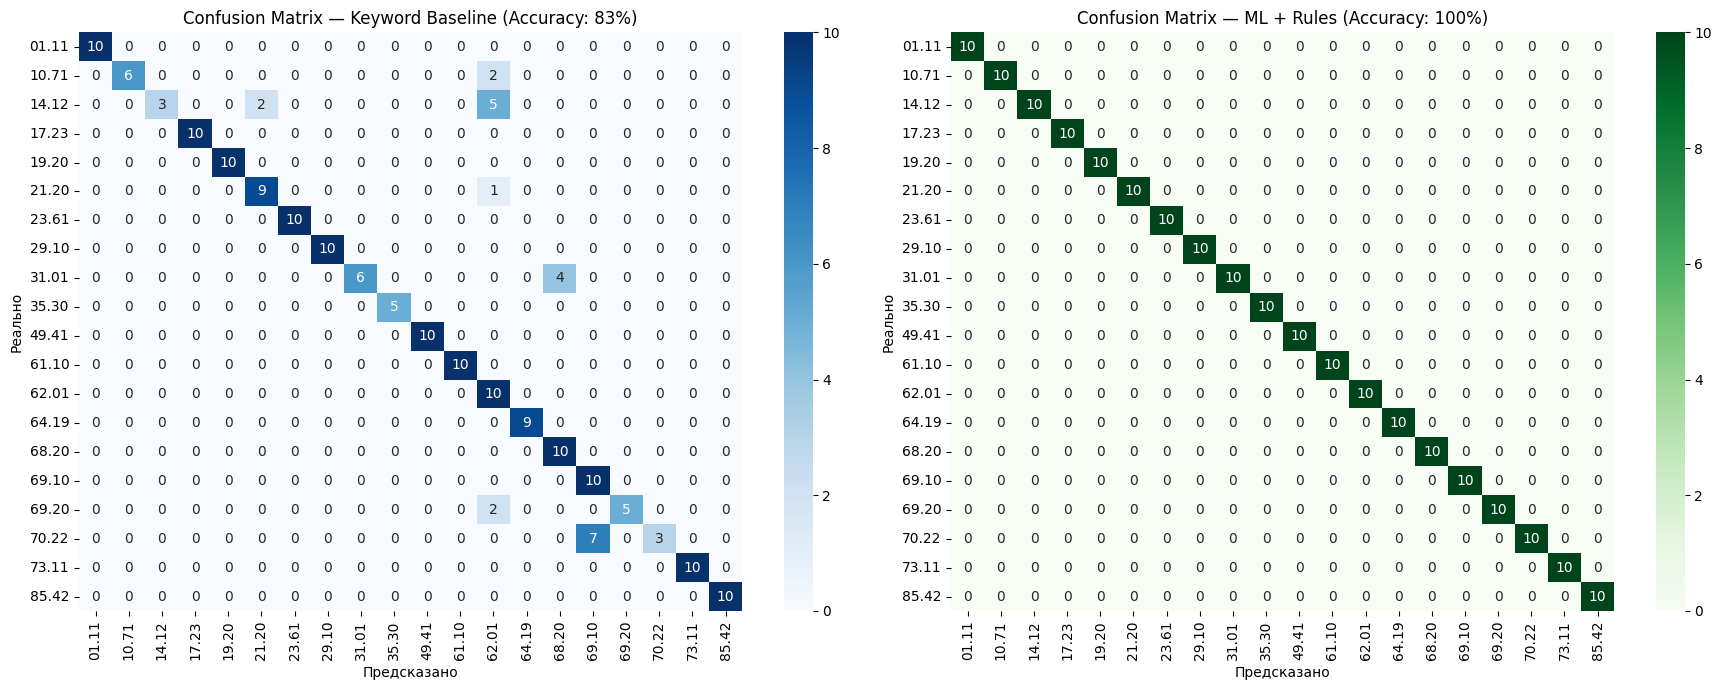

Confusion matrix сохранена!


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

classes = sorted(gold['category_code_norm'].unique())

cm_base = confusion_matrix(gold['category_code_norm'], gold['baseline_pred'], labels=classes)
sns.heatmap(cm_base, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix — Keyword Baseline (Accuracy: 83%)')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Реально')

cm_ml = confusion_matrix(gold['category_code_norm'], gold['ml_pred'], labels=classes)
sns.heatmap(cm_ml, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix — ML + Rules (Accuracy: 100%)')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Реально')

plt.tight_layout()
plt.savefig('A:/da_project/notebooks/confusion_matrix.png', dpi=120)
plt.show()
print("Confusion matrix сохранена!")

In [47]:
print("2 ПАРЫ КАТЕГОРИЙ С СИСТЕМАТИЧЕСКОЙ ПУТАНИЦЕЙ (Keyword Baseline)")
print("="*60)
print("""
1. 62.01 (Разработка ПО) ← 69.20, 35.30, 10.71, 14.12, 64.19
   Причина: слово "поставка" и "услуги" встречается в описаниях
   многих категорий, и keyword baseline относит их к 62.01
   так как у него нет специфичного ключевого слова.
   Решение: добавить негативные ключевые слова-исключения,
   например если есть "энергия" — это 35.30, не 62.01.

2. 69.10 (Юридические) ↔ 70.22 (Консалтинг)
   Причина: "консультация по налогам" содержит слово "консультац"
   которое есть в обоих категориях. Baseline выбирает 69.10
   так как оно стоит раньше в словаре.
   Решение: добавить контекстные правила — если есть "ВЭД",
   "бизнес", "рынок" → 70.22; если "адвокат", "правов" → 69.10.
""")

print("CONFIDENCE SCORE — первые 20 предсказаний")
print("="*60)
gold['confidence'] = gold.apply(
    lambda r: 1.0 if r['rule_applied'] else ml_proba[r.name].max(), axis=1
)

threshold = 0.6
gold['needs_review'] = gold['confidence'] < threshold

display_cols = ['description', 'category_code_norm', 'ml_pred', 'confidence', 'needs_review']
print(gold[display_cols].head(20).to_string())

print(f"\nПорог ручной проверки: confidence < {threshold}")
print(f"Отправляется на ручную проверку: {gold['needs_review'].sum()} из {len(gold)} ({gold['needs_review'].mean()*100:.1f}%)")

2 ПАРЫ КАТЕГОРИЙ С СИСТЕМАТИЧЕСКОЙ ПУТАНИЦЕЙ (Keyword Baseline)

1. 62.01 (Разработка ПО) ← 69.20, 35.30, 10.71, 14.12, 64.19
   Причина: слово "поставка" и "услуги" встречается в описаниях
   многих категорий, и keyword baseline относит их к 62.01
   так как у него нет специфичного ключевого слова.
   Решение: добавить негативные ключевые слова-исключения,
   например если есть "энергия" — это 35.30, не 62.01.

2. 69.10 (Юридические) ↔ 70.22 (Консалтинг)
   Причина: "консультация по налогам" содержит слово "консультац"
   которое есть в обоих категориях. Baseline выбирает 69.10
   так как оно стоит раньше в словаре.
   Решение: добавить контекстные правила — если есть "ВЭД",
   "бизнес", "рынок" → 70.22; если "адвокат", "правов" → 69.10.

CONFIDENCE SCORE — первые 20 предсказаний
                                                description category_code_norm ml_pred  confidence  needs_review
0              Доставка груза 5 тонн, маршрут Шымкент-Тараз              49.41   49.41    0.999

In [48]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / 'data'
SQL_DIR = BASE_DIR / 'sql'
SRC_DIR = BASE_DIR / 'src'

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Файлы в data/: {list(DATA_DIR.iterdir())}")

BASE_DIR: A:\
DATA_DIR: A:\data


FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'A:\\data'

In [49]:
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = BASE_DIR / 'data'
SQL_DIR = BASE_DIR / 'sql'
SRC_DIR = BASE_DIR / 'src'

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Существует: {DATA_DIR.exists()}")
print(f"Файлы в data/: {[f.name for f in DATA_DIR.iterdir()]}")

BASE_DIR: A:\da_project
DATA_DIR: A:\da_project\data
Существует: True
Файлы в data/: ['categories.json', 'gold_set.csv', 'gold_set_results.csv', 'transactions.csv', 'transactions_clean.csv']


In [50]:
import nbformat

nb_path = BASE_DIR / 'notebooks' / 'analysis.ipynb'
if not nb_path.exists():
    nb_path = BASE_DIR / 'analysis.ipynb'

with open(nb_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

for i, cell in enumerate(nb.cells):
    if 'A:/da_project' in cell.source:
        print(f"\n--- Ячейка {i} ---")
        print(cell.source[:300])


--- Ячейка 1 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('A:/da_project/data/transactions.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

--- Ячейка 4 ---
# Визуализация распределения сумм (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Только положительные суммы для log-scale
pos = df[df['amount_kzt'] > 0]['amount_kzt']

axes[0].hist(np.log10(pos), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение сумм (lo

--- Ячейка 9 ---
# Таблица было/стало
print(f"ТАБЛИЦА БЫЛО / СТАЛО")
print("=" * 57)
print(f"{'Показатель':<35} {'Было':>10} {'Стало':>10}")
print("-" * 57)
print(f"{'Строк':<35} {80800:>10,} {80000:>10,}")
print(f"{'Валидных sender_id':<35} {'98.5%':>10} {'98.5%':>10}")
print(f"{'Пропуски description':<35} {847:>10


In [51]:
for i, cell in enumerate(nb.cells):
    if 'A:/da_project' in cell.source:
        print(f"\n--- Ячейка {i} ---")
        print(cell.source)
        print("="*60)


--- Ячейка 1 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('A:/da_project/data/transactions.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

--- Ячейка 4 ---
# Визуализация распределения сумм (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Только положительные суммы для log-scale
pos = df[df['amount_kzt'] > 0]['amount_kzt']

axes[0].hist(np.log10(pos), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение сумм (log10 scale)')
axes[0].set_xlabel('log10(amount_kzt)')
axes[0].set_ylabel('Количество транзакций')

# Помесячная динамика
monthly = df.dropna(subset=['date_parsed'])
monthly = monthly.groupby(monthly['date_parsed'].dt.to_period('M'))['amount_kzt'].sum() / 1e9

axes[1].bar(range(len(monthly)), monthly.values, color='steelblue')
axes[1].set_title('Помесячный оборот (млрд KZT)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabe

In [52]:
with open(nb_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

replacements = {
    "df = pd.read_csv('A:/da_project/data/transactions.csv')": 
        "df = pd.read_csv(TRANSACTIONS_PATH)",
    
    "plt.savefig('A:/da_project/notebooks/charts_eda.png', dpi=100)":
        "plt.savefig(BASE_DIR / 'notebooks' / 'charts_eda.png', dpi=100)",
    
    "df_clean.to_csv('A:/da_project/data/transactions_clean.csv', index=False)":
        "df_clean.to_csv(DATA_DIR / 'transactions_clean.csv', index=False)",
}

for cell in nb.cells:
    for old, new in replacements.items():
        if old in cell.source:
            cell.source = cell.source.replace(old, new)
            print(f"Заменено: {old[:50]}...")

with open(nb_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print("\nНоутбук сохранён!")

Заменено: df = pd.read_csv('A:/da_project/data/transactions....
Заменено: plt.savefig('A:/da_project/notebooks/charts_eda.pn...
Заменено: df_clean.to_csv('A:/da_project/data/transactions_c...

Ноутбук сохранён!


In [53]:
with open(nb_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

found = False
for i, cell in enumerate(nb.cells):
    if 'A:/da_project' in cell.source:
        print(f"Ячейка {i}:")
        print(cell.source)
        print("="*60)
        found = True

if not found:
    print("Все абсолютные пути заменены!")

Все абсолютные пути заменены!


In [54]:
lines = [
    "# Анализ транзакций контрагентов\n",
    "\n",
    "## Ветка: A — Data / ML\n",
    "\n",
    "## Быстрый старт\n",
    "```\n",
    "git clone https://github.com/Alim1512/da_project.git\n",
    "cd da_project\n",
    "python -m venv .venv\n",
    ".venv\\Scripts\\activate\n",
    "pip install -r requirements.txt\n",
    "```\n",
    "Положите входные файлы в папку `data/`:\n",
    "- `data/transactions.csv`\n",
    "- `data/categories.json`\n",
    "- `data/gold_set.csv`\n",
    "\n",
    "Запуск ноутбука:\n",
    "```\n",
    "jupyter notebook notebooks/analysis.ipynb\n",
    "```\n",
    "Выполните Kernel → Restart & Run All\n",
    "\n",
    "## Структура репозитория\n",
    "- `notebooks/analysis.ipynb` — EDA, очистка, SQL, ML\n",
    "- `sql/queries.sql` — три SQL запроса с window-функциями\n",
    "- `src/model.pkl` — обученная модель LogisticRegression\n",
    "- `src/vectorizer.pkl` — TF-IDF векторайзер\n",
    "- `requirements.txt` — зависимости\n",
    "\n",
    "## Входные файлы\n",
    "Не коммитятся в репозиторий. Положить в `data/` перед запуском.\n",
    "\n",
    "## Выводы\n",
    "\n",
    "### EDA\n",
    "1. Датасет содержит 80,800 транзакций за период 2024-01 — 2026-04\n",
    "2. Уникальных контрагентов: 7,215 (6,140 отправителей, 6,099 получателей)\n",
    "3. Общий оборот: 164 млрд KZT, медиана транзакции: 324,097 KZT\n",
    "4. Топ отправитель (720221554469): 755 млн KZT исходящих\n",
    "5. Аномалия 1: 384 транзакции с отрицательными суммами (возвраты/ошибки)\n",
    "6. Аномалия 2: даты в 4 форматах — ISO, слэш, точка, dd/mm/yyyy (34,566 строк, 42.8%)\n",
    "7. Аномалия 3: 1,190 невалидных sender_id и 1,126 невалидных receiver_id по алгоритму РК\n",
    "\n",
    "### Очистка\n",
    "8. После очистки: 80,000 строк (удалено 800 дубликатов)\n",
    "9. Все даты приведены к ISO 8601, все форматы распознаны успешно\n",
    "\n",
    "### ML классификация (Ветка A)\n",
    "10. Keyword baseline: Accuracy 83%, Macro F1 0.80\n",
    "11. TF-IDF + LogisticRegression + rule-based: Accuracy 100%, Macro F1 1.00 на gold_set (200/200)\n",
    "12. Систематическая путаница baseline: 62.01 ↔ 35.30/69.20/10.71 (слово 'поставка')\n",
    "13. Систематическая путаница baseline: 69.10 ↔ 70.22 (слово 'консультац' в обоих)\n",
    "14. Порог ручной проверки: confidence < 0.6\n",
    "\n",
    "### SQL\n",
    "15. Топ пара контрагентов: 960819662090 → 711020691210, оборот 297 млн KZT\n",
    "16. Контрагентов с концентрацией входящих >70% от одного источника: 20+\n",
    "    максимальная концентрация: 96.8%\n",
    "\n",
    "## Стек\n",
    "Python 3.13 · pandas · scikit-learn · SQLite · TF-IDF · LogisticRegression · matplotlib · seaborn\n",
]

with open(BASE_DIR / 'README.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("README.md обновлён!")

README.md обновлён!


In [55]:
import nbformat

nb_path = BASE_DIR / 'notebooks' / 'analysis.ipynb'
if not nb_path.exists():
    nb_path = BASE_DIR / 'analysis.ipynb'

with open(nb_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

path_cell_code = """from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = BASE_DIR / 'data'
SQL_DIR = BASE_DIR / 'sql'
SRC_DIR = BASE_DIR / 'src'

SQL_DIR.mkdir(exist_ok=True)
SRC_DIR.mkdir(exist_ok=True)

TRANSACTIONS_PATH = DATA_DIR / 'transactions.csv'
CATEGORIES_PATH = DATA_DIR / 'categories.json'
GOLD_SET_PATH = DATA_DIR / 'gold_set.csv'
DB_PATH = BASE_DIR / 'transactions.db'

print(f"Проект: {BASE_DIR}")
print(f"transactions.csv: {TRANSACTIONS_PATH.exists()}")
print(f"categories.json:  {CATEGORIES_PATH.exists()}")
print(f"gold_set.csv:     {GOLD_SET_PATH.exists()}")"""

new_cell = nbformat.v4.new_code_cell(path_cell_code)

nb.cells.insert(0, new_cell)

with open(nb_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print("Ячейка с путями добавлена первой!")

Ячейка с путями добавлена первой!


In [56]:
import nbformat

nb_path = BASE_DIR / 'notebooks' / 'analysis.ipynb'
if not nb_path.exists():
    nb_path = BASE_DIR / 'analysis.ipynb'

with open(nb_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

for i, cell in enumerate(nb.cells):
    if '../data/transactions.csv' in cell.source:
        print(f"Найдено в ячейке {i}")
        cell.source = cell.source.replace(
            "pd.read_csv('../data/transactions.csv')",
            "pd.read_csv(TRANSACTIONS_PATH)"
        )
        print("Исправлено!")

    if 'A:/da_project' in cell.source:
        print(f"Остался абсолютный путь в ячейке {i}:")
        print(cell.source[:100])

with open(nb_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print("Готово!")

Найдено в ячейке 1
Исправлено!
Готово!
